### **The Time-Dependent Schrodinger Equation**

The Time Dependent Schrodinger Equation (in a position basis infinite bounderies) is

$$i\hbar{\frac{\partial}{\partial t}}\psi(x,t)=-{\frac{\hbar^{2}}{2m}}{\frac{\partial^{2}}{\partial x^{2}}}\psi(x,t)+V(x)\psi(x,t)\qquad\qquad\psi(0,t)=\psi(L,t)=0$$

We don't need with extra parameters like $m,\hbar,$ etc. Multiplying both sides by $mL^2$ where $L$ is the characteristic length of the problem (here we are bounded in length $L$)

$$i m L^{2}\hbar\frac{\partial}{\partial t}\psi=-\frac{1}{2}\hbar^{2}L^{2}\frac{\partial^{2}}{\partial x^{2}}\psi+m L^{2}V(x)\psi$$

Now choose the convention $\hbar = 1$ (So Joules=1/Seconds) and make the transformation


- $ x^\prime = x/L $
- $ t^\prime = t/m L^2 $
- $ V^\prime = m L^{2}V $

You can check that with the convention $\hbar = 1$, all of the three quantities above are dimensionless. The Schrodiger Equation with respect to these three varibales becomes

$$i\frac{\partial}{\partial t^{\prime}}\psi=-\frac{1}{2}\frac{\partial^{2}}{\partial x^{\prime 2}}\psi+V^{\prime}(x)\psi$$

We solve this equation for $x^{\prime}$ and $t^{\prime}$ and then solve for $x$ and $t$ using

- $ x=Lx^{\prime} $
- $ t=(mL^2)t^{\prime} $
- $ V=(mL^2)^{-1}V^{\prime} $

**For all the numerical work we will drop the primes on $x^{\prime}, t^{\prime}$ and $V^{\prime}$ but know that we are working with the primed quantities.**

### **Technique 1: Finite Difference**

choose a discrete grid with spacing $\Delta x$ and $\Delta t$ and let $\psi_j^m = \psi(j \Delta x,m \Delta t)$

$$i\frac{{\psi}_{j}^{m+1}-\psi_{j}^{m}}{\Delta t}=-\frac{1}{2}\frac{\psi_{j+1}^{m}-2\psi_{j}^{m}+\psi_{j-1}^{m}}{\Delta x^{2}}+V(x)\psi_{j}^{m}$$

Rearrange the equation

$$\psi_{j}^{m+1}=\psi_{j}^{m}+\frac i2\frac{\Delta t}{\Delta x^{2}}\left(\psi_{j+1}^{m}-2\psi_{j}^{m}+\psi_{j-1}^{m}\right)-i\Delta t V(x)\psi_{j}^{m}$$

### **Technique 2: Eigenstate Evolution**

Find the $\psi_j$ and $E_j$'s that satisfy

$$-{\frac{1}{2}}{\frac{\partial^{2}}{\partial x^{2}}}\psi+V(x)\psi=E\psi$$

And then

$$\psi(x,t)=\sum_{j=0}^{\infty}c_{j}\psi_{j}(x)e^{-i E_{j}t} \qquad\qquad c_{j}=\int_{-\infty}^{\infty}\psi(x,0)\psi_{j}^{*}(x)dx$$

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.animation import PillowWriter
import numba
from numba import jit
from scipy.linalg import eigh_tridiagonal
import scienceplots
plt.style.use(['science','notebook', 'grid'])

### **Technique 1**

Define all parameters of interest

In [2]:
Nx = 301
Nt = 100000
dx = 1/(Nx -1)
dt = 1e-7
x = np.linspace(0,1,Nx)
psi0 = np.sqrt(2)*np.sin(np.pi*x)
mu, sigma = 1/2,1/20
V = -1e4*np.exp(
    -(x-mu)**2/(2*sigma**2)
)

In [3]:
np.sum(np.absolute(psi0)**2)*dx

1.0

Lookk at $dt/dx^2$ (this parameter should be small for the finite difference method to work).

In [4]:
dt/dx**2

0.008999999999999998

The (dimensionless) potential we examine here is

$$
V(x) = -10^4 \exp(\frac{-(x-L/2)^2}{2(L/20)^2})
$$
which is essentially just a normal curve which can be specified more simply as $V(x)=-n(x,\mu = L/2, \sigma = L/20)$

Text(0, 0.5, '$V(x)$')

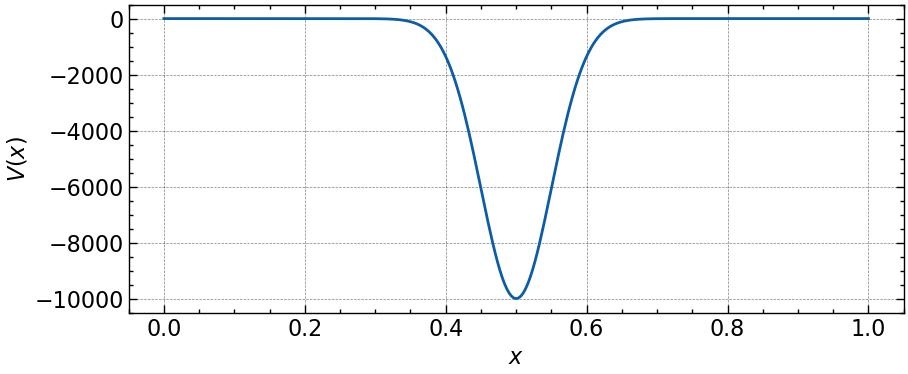

In [5]:
plt.figure(figsize=(10,4))
plt.plot(x,V)
plt.xlabel('$x$')
plt.ylabel('$V(x)$')

Construct the array of $\psi(x,t)$ (two dimension: one for x and one for t)

In [6]:
psi = np.zeros([Nt,Nx])
psi[0] = psi0
psi

array([[0.00000000e+00, 1.48093391e-02, 2.96170542e-02, ...,
        2.96170542e-02, 1.48093391e-02, 1.73191211e-16],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]])

Numba algorithm to implement the finite difference method

In [7]:
@numba.jit("c16[:,:](c16[:,:])", nopython=True, nogil=True)
def compute_psi(psi):
    dx2 = dx**2  
    dt_dx2 = dt / dx2  

    for t in range(0, Nt - 1):
        for i in range(1, Nx - 1):
            psi[t + 1, i] = (
                psi[t, i]
                + 1j / 2 * dt_dx2 * (psi[t, i + 1] - 2 * psi[t, i] + psi[t, i - 1])
                - 1j * dt * V[i] * psi[t, i]
            )
        
        norm = np.sqrt(np.sum(np.absolute(psi[t + 1])**2) * dx)
        psi[t + 1] /= norm

    return psi


Compute $\psi(x,t)$ using method 1 (so we label m1)

In [8]:
psi_m1 = compute_psi(psi.astype(complex))

Plot for some given $m=10000$ (the dimensionless time is $t=m\Delta t$)

1.0000000000000002

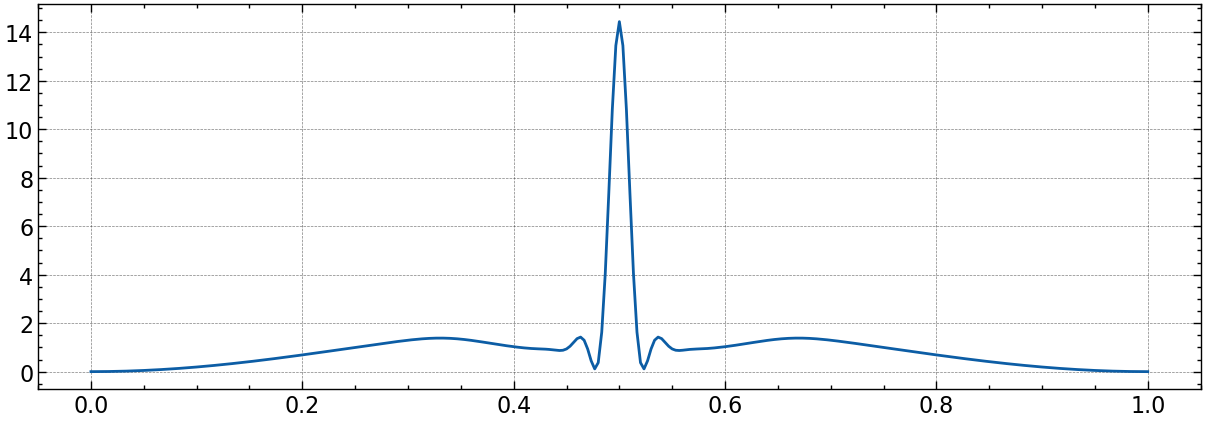

In [9]:
plt.figure(figsize=(15,5))
plt.plot(x, np.absolute(psi_m1[10000])**2)
np.sum(np.absolute(psi_m1[10000])**2)*dx

### **Technique 2**

Create the grid and define the initial condition $\psi(x,0)$

In [10]:
Nx = 301
dx = 1/(Nx-1)
x = np.linspace(0,1,Nx)
psi0 = np.sqrt(2)*np.sin(np.pi*x)

def V(x):
    mu, sigma = 1/2, 1/20
    return -1e4*np.exp(-(x-1/2)**2/(2*(1/20)**2))

Define the tridiagonal matrix required for solving for the eigenstates

In [11]:
d = 1/dx**2 + V(x)[1:-1]
e = -1/(2*(dx**2)*np.ones(len(d)-1))
w, v = eigh_tridiagonal(d,e)

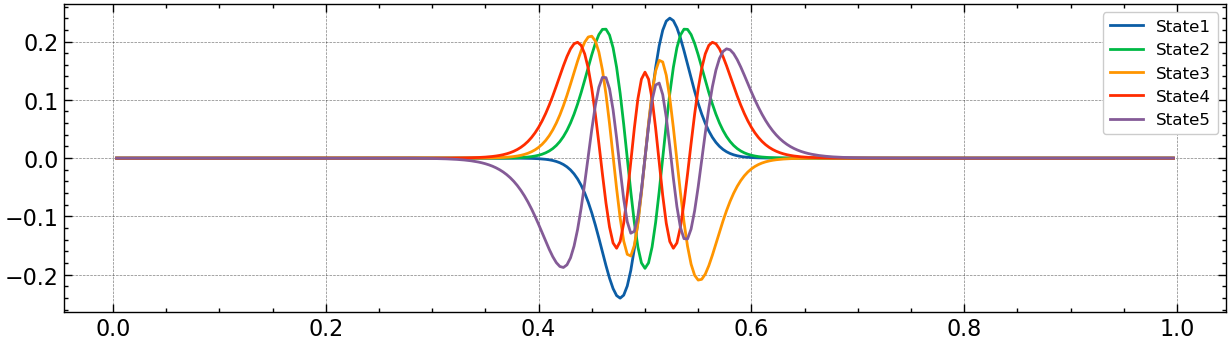

In [12]:
def plot(initial_state, finial_state):
    i = initial_state
    plt.figure(figsize=(15,4))

    while i <= finial_state:
        plt.plot(x[1:-1], v.T[i], label= f'State{i}')
        i += 1
    
    plt.legend(loc='upper right', fontsize=12) 

plot(1,5)

Compute eigenstates $\psi_j$ and eigen-energies $E_j$, and use

$$
\psi(x,t) = \sum_{j=0}^{\infty} c_j \psi_j(x) e^{-iE_j t}
$$

$$
c_j = \int_{-\infty}^\infty \psi(x,0)\psi_j^{*}(x)dx
$$

to get the $\psi(x,t)$

In [13]:
E_js = w[0:70]
psi_js = np.pad(v.T[0:70], [(0,0),(1,1)], mode='constant')
cs = np.dot(psi_js, psi0)

def psi_m2(t):
    return psi_js.T@(cs * np.exp(-1j * E_js * t))


Plot the energy at time $t=10000\Delta t$

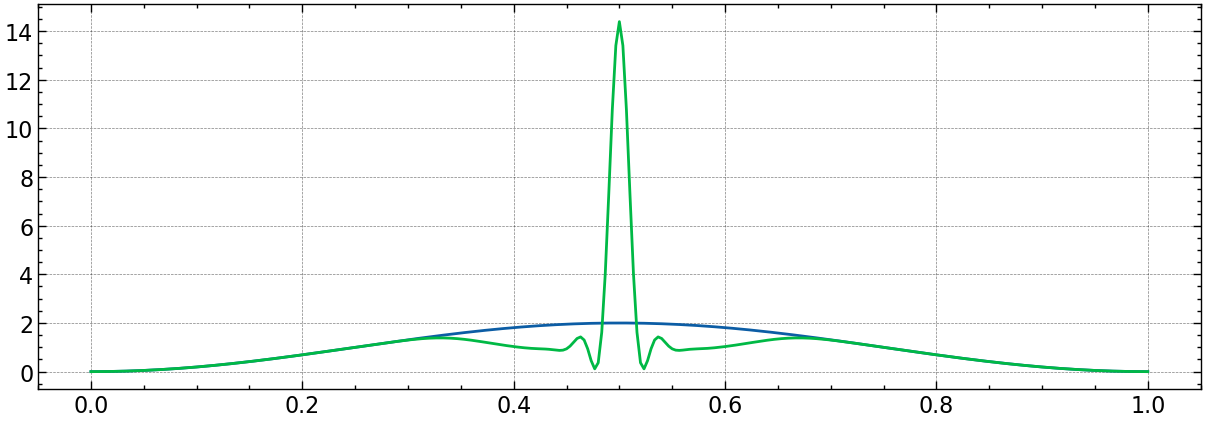

In [14]:
plt.figure(figsize=(15,5))
plt.plot(x, psi0**2)
plt.plot(x, np.absolute(psi_m2(10000 * dt))**2)

### **Animation**

Now we make an animation that shows the results of the two techniques, and that they give the same result.

<>:14: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\c'
<>:14: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\c'
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24884\836950568.py:14: SyntaxWarning: invalid escape sequence '\p'
  ax.set_ylabel('$|\psi(x)^2|$', fontsize=20)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24884\836950568.py:17: SyntaxWarning: invalid escape sequence '\c'
  ax.set_title('$(mL^2)V(x) = -10^4 \cdot n(x, \mu=L/2,\sigma= L/20)$')


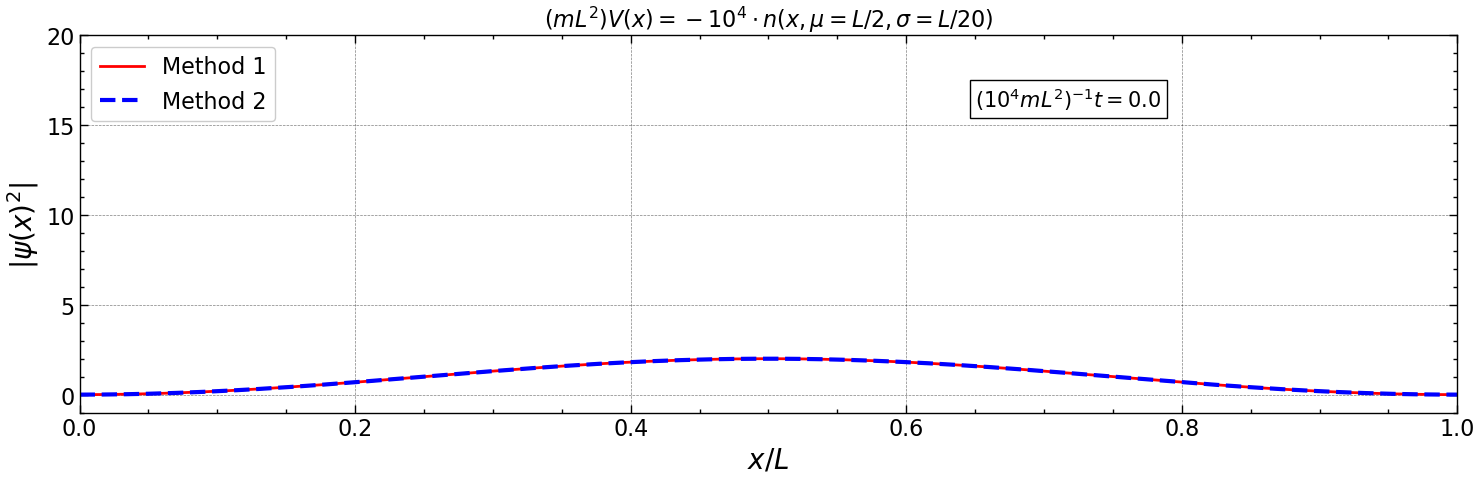

In [15]:
def animate(i):
    ln1.set_data(x, np.absolute(psi_m1[100*i]**2))
    ln2.set_data(x, np.absolute(psi_m2(100*i*dt))**2)
    time_text.set_text('$(10^4 mL^2)^{-1}t=$'+'{:.1f}'.format(100*i*dt*1e4))

fig, ax = plt.subplots(1,1,figsize=(15,5))

ln1, = plt.plot([],[],'r-', lw=2, markersize=8,label='Method 1')
ln2, = plt.plot([],[],'b--', lw=3, markersize=8,label='Method 2')
time_text = ax.text(0.65, 16, '', fontsize=15, bbox=dict(facecolor='white', edgecolor='black'))

ax.set_ylim(-1,20)
ax.set_xlim(0,1)
ax.set_ylabel('$|\psi(x)^2|$', fontsize=20)
ax.set_xlabel('$x/L$', fontsize=20)
ax.legend(loc='upper left')
ax.set_title('$(mL^2)V(x) = -10^4 \cdot n(x, \mu=L/2,\sigma= L/20)$')
plt.tight_layout()
ani = animation.FuncAnimation(fig,animate, frames=1000, interval=50)
ani.save('TD.gif',writer='pillow', fps=50, dpi=100)